## LSTM & RNN

*  RNN has only short term memory

*  LSTM has short term(hidden) and long term memory (cell state)
*  LSTM gates control what information is kept, updated, or forgotten






In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# This relates to plotting datetime values with matplotlib:
# from pandas.plotting import register_matplotlib_converters
# register_matplotlib_converters()

### reading data, indexing with date column

In [2]:
df = pd.read_csv("Alcohol_Sales.csv", parse_dates=["DATE"], index_col="DATE") # parse_dates : Pandas converts "DATE" into a datetime object00
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 325 entries, 1992-01-01 to 2019-01-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   S4248SM144NCEN  325 non-null    int64
dtypes: int64(1)
memory usage: 5.1 KB


In [3]:
# top 5 rows
df.head()

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


In [4]:
# total length of the data
len(df)

325

### line graph of alchol sales

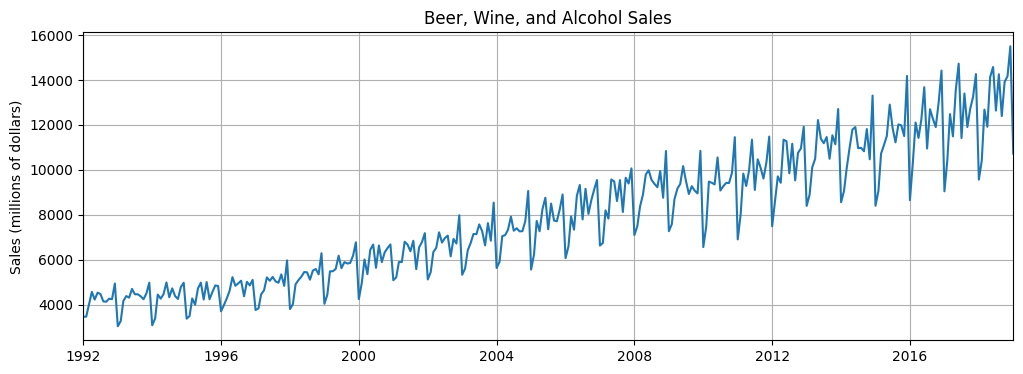

In [5]:
plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True) #plt.autoscale(axis='x',tight=True) eliminating  padding or margin
plt.plot(df['S4248SM144NCEN'])
plt.show()

# Prepare data

### changing column to float datatype

In [6]:

y = df['S4248SM144NCEN'].values.astype(float)
print("data type", y.dtype)
print(y)



data type float64
[ 3459.  3458.  4002.  4564.  4221.  4529.  4466.  4137.  4126.  4259.
  4240.  4936.  3031.  3261.  4160.  4377.  4307.  4696.  4458.  4457.
  4364.  4236.  4500.  4974.  3075.  3377.  4443.  4261.  4460.  4985.
  4324.  4719.  4374.  4248.  4784.  4971.  3370.  3484.  4269.  3994.
  4715.  4974.  4223.  5000.  4235.  4554.  4851.  4826.  3699.  3983.
  4262.  4619.  5219.  4836.  4941.  5062.  4365.  5012.  4850.  5097.
  3758.  3825.  4454.  4635.  5210.  5057.  5231.  5034.  4970.  5342.
  4831.  5965.  3796.  4019.  4898.  5090.  5237.  5447.  5435.  5107.
  5515.  5583.  5346.  6286.  4032.  4435.  5479.  5483.  5587.  6176.
  5621.  5889.  5828.  5849.  6180.  6771.  4243.  4952.  6008.  5353.
  6435.  6673.  5636.  6630.  5887.  6322.  6520.  6678.  5082.  5216.
  5893.  5894.  6799.  6667.  6374.  6840.  5575.  6545.  6789.  7180.
  5117.  5442.  6337.  6525.  7216.  6761.  6958.  7070.  6148.  6924.
  6716.  7975.  5326.  5609.  6414.  6741.  7144.  7133.  7

### Train and test data split

In [7]:
# Define a test size
test_size = 12

# Create train and test sets
train_set = y[:-test_size]
print("train length: ", train_set.shape)
test_set = y[-test_size:]
print("test length: ", test_set.shape)

train length:  (313,)
test length:  (12,)


### Train set

In [8]:
train_set

array([ 3459.,  3458.,  4002.,  4564.,  4221.,  4529.,  4466.,  4137.,
        4126.,  4259.,  4240.,  4936.,  3031.,  3261.,  4160.,  4377.,
        4307.,  4696.,  4458.,  4457.,  4364.,  4236.,  4500.,  4974.,
        3075.,  3377.,  4443.,  4261.,  4460.,  4985.,  4324.,  4719.,
        4374.,  4248.,  4784.,  4971.,  3370.,  3484.,  4269.,  3994.,
        4715.,  4974.,  4223.,  5000.,  4235.,  4554.,  4851.,  4826.,
        3699.,  3983.,  4262.,  4619.,  5219.,  4836.,  4941.,  5062.,
        4365.,  5012.,  4850.,  5097.,  3758.,  3825.,  4454.,  4635.,
        5210.,  5057.,  5231.,  5034.,  4970.,  5342.,  4831.,  5965.,
        3796.,  4019.,  4898.,  5090.,  5237.,  5447.,  5435.,  5107.,
        5515.,  5583.,  5346.,  6286.,  4032.,  4435.,  5479.,  5483.,
        5587.,  6176.,  5621.,  5889.,  5828.,  5849.,  6180.,  6771.,
        4243.,  4952.,  6008.,  5353.,  6435.,  6673.,  5636.,  6630.,
        5887.,  6322.,  6520.,  6678.,  5082.,  5216.,  5893.,  5894.,
      

### scaling

In [9]:
from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import StandardScaler

# Instantiate a scaler with a feature range from -1 to 1
scaler = MinMaxScaler(feature_range=(-1, 1))
# scaler = StandardScaler()
scaler

,feature_range,"(-1, ...)"
,copy,True
,clip,False


### scaling train and test data

In [10]:
# Normalize the training set
train_norm = scaler.fit_transform(train_set.reshape(-1, 1)) # 1 column
# print(train_norm.ndim)
print(train_norm.shape)

test_norm  = scaler.transform(test_set.reshape(-1, 1))
print(test_norm)

(313, 1)
[[0.26233011]
 [0.65005556]
 [0.51944611]
 [0.89879477]
 [0.97486965]
 [0.6427045 ]
 [0.91913839]
 [0.60099154]
 [0.8605009 ]
 [0.90494914]
 [1.132319  ]
 [0.31412941]]


In [11]:
# train_norm.max()

### defining  sequence function

In [12]:
# Convert train_norm from an array to a tensor
train_norm = torch.FloatTensor(train_norm).view(-1) # convert to 1D


# Define a window size
window_size = 12 # LSTM cell runs 12 recurrent steps for that input sequence.

# Define function to create seq/label tuples
def create_sequence(seq,ws):  # ws is the window size 12
    sequences = []
    L = len(seq) # 24 (0-23)
    for i in range(L-ws): # 24-12 =12 = (0 to 11)
        window = seq[i:i+ws] # 0-11, 1-12, ...11-22
        #label = seq[i+ws] # 12, 13, ....23
        label  = seq[i+ws:i+ws+1] 
        sequences.append((window,label)) # add sequence and label
    return sequences 


### creating sequence for train data

In [13]:
# Apply the input_data function to train_norm
train_data = create_sequence(train_norm,window_size)



In [14]:
print(train_data[0])
print(train_data[1])

(tensor([-0.9268, -0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109,
        -0.8128, -0.7901, -0.7933, -0.6743]), tensor([-1.]))
(tensor([-0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109, -0.8128,
        -0.7901, -0.7933, -0.6743, -1.0000]), tensor([-0.9607]))


### Defining LSTM Layer 

###

In [ ]:
# # # Define model
hidden_size = 128
class LSTMnetwork(nn.Module):
    # just one value at each time step i.e input size is 1
    def __init__(self,input_size=1,hidden_size=hidden_size,output_size=1): # hidden size (128) means at each step - 12 window period, the hidden state (ht​ , Ct​) vector of 128 values
        super().__init__()
        self.hidden_size = hidden_size

        # Add an LSTM layer:
        self.lstm = nn.LSTM(input_size,hidden_size)

        # Add a fully-connected layer:
        self.linear = nn.Linear(hidden_size,output_size) # maps 128 dimensions because hidden state  into final prediction


    def forward(self, seq): # function defines how data flows.
        # seq: 1D tensor of shape (seq_len,)
        seq = seq.view(len(seq), 1, 1)  # (seq_len, batch=1, input_size=1)

        # Initialize hidden & cell state for each forward pass
        h0 = torch.zeros(1, 1, self.hidden_size)
        c0 = torch.zeros(1, 1, self.hidden_size)

        lstm_out, _ = self.lstm(seq, (h0, c0))   # lstm_out: (seq_len, 1, hidden_size)
        

        # Use the last time step's output
        last_time_step = lstm_out[-1]            # (1, hidden_size)
        pred = self.linear(last_time_step)       # (1, output_size)
        return pred  # shape (1, 1)

# import torch
# import torch.nn as nn

# UPDATED MODEL - Bigger, deeper, better
# class LSTMnetwork(nn.Module):
#     def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.num_layers = num_layers
        
#         # 2-layer LSTM with 256 hidden units + dropout
#         self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
#                            dropout=0.2, batch_first=False)
#         self.linear = nn.Linear(hidden_size, output_size)

#     def forward(self, seq):
#         # seq: 1D tensor (seq_len,)
#         seq = seq.view(len(seq), 1, 1)  # (seq_len, batch=1, input_size=1)
        
#         # Multi-layer hidden/cell state initialization
#         h0 = torch.zeros(self.num_layers, 1, self.hidden_size)
#         c0 = torch.zeros(self.num_layers, 1, self.hidden_size)
        
#         # LSTM forward pass
#         lstm_out, _ = self.lstm(seq, (h0, c0))  # lstm_out: (seq_len, 1, hidden_size)
        
#         # Use last time step output
#         last_time_step = lstm_out[-1]  # (1, hidden_size)
#         pred = self.linear(last_time_step)  # (1, 1)
#         return pred

# # Usage:
# model = LSTMnetwork(hidden_size=256, num_layers=2)  # 4x more powerful!
# print(model)


I'll update the notebook plotting cell to add the recursive (predicted→predicted) forecast and plot its line and error alongside the existing teacher-forced predictions. I'll edit the code cell directly.

Generating patch (105 lines) in [](file:///Users/nikc/Desktop/Research/RNN%26LSTM.ipynb)

Updated — the plotting cell now shows three lines: Actual, Predicted (teacher-forced), and Predicted (recursive), plus both error series. Run that cell in your notebook to view the plot; want me to execute it and show the outputs?

Made changes.

#  Instantiate the model, define loss and optimization functions

In [16]:
torch.manual_seed(42)
model = LSTMnetwork()

criterion = nn.MSELoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=0.003) # Optimization update the model’s weights so that the loss becomes smaller

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #
#optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

model

LSTMnetwork(
  (lstm): LSTM(1, 128)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)

### Model Summary

In [17]:
! pip install torchinfo
from torchinfo import summary

print(summary(model, input_size=(12, 1, 1))) # seq_len=24, batch=1, features=1


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.14/bin/python3.14 -m pip install --upgrade pip
Layer (type:depth-idx)                   Output Shape              Param #
LSTMnetwork                              [1, 1]                    --
├─LSTM: 1-1                              [12, 1, 128]              67,072
├─Linear: 1-2                            [1, 1]                    129
Total params: 67,201
Trainable params: 67,201
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.80
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.27
Estimated Total Size (MB): 0.28


### input_size =[ 24 time steps, 1 batch, 1 features]

### LSTM output: [24 time steps, 1 batch, 100 features]

### Linear layer receives [12, 100]

### Linear layer receives [12, 1]

### model only returns the last prediction due to pred[-1]  


In [18]:

# ! pip install torch-summary
# from torchsummary import summary
# print(summary(model, input_size=(24, 1, 1)))

## Training data
### trains the LSTM model for 100 epochs
### computing the loss, backpropagating errors, and updating weights using the optimizer
### plots the loss curve to show how learning improves over time.


/Users/nikc/Library/Python/3.14/lib/python/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 1 Loss: 0.04920069
Epoch: 2 Loss: 0.06382659
Epoch: 3 Loss: 0.05840235
Epoch: 4 Loss: 0.04438981
Epoch: 5 Loss: 0.03346837
Epoch: 6 Loss: 0.03413525
Epoch: 7 Loss: 0.03285149
Epoch: 8 Loss: 0.03535891
Epoch: 9 Loss: 0.03522966
Epoch: 10 Loss: 0.03716291
Epoch: 11 Loss: 0.03571353
Epoch: 12 Loss: 0.03658931
Epoch: 13 Loss: 0.03570586
Epoch: 14 Loss: 0.03921096
Epoch: 15 Loss: 0.03665945
Epoch: 16 Loss: 0.03682488
Epoch: 17 Loss: 0.03504191
Epoch: 18 Loss: 0.03497545
Epoch: 19 Loss: 0.02679268
Epoch: 20 Loss: 0.02264311
Epoch: 21 Loss: 0.03063827
Epoch: 22 Loss: 0.02467974
Epoch: 23 Loss: 0.02783040
Epoch: 24 Loss: 0.02263866
Epoch: 25 Loss: 0.02111985
Epoch: 26 Loss: 0.02203743
Epoch: 27 Loss: 0.03153363
Epoch: 28 Loss: 0.06171501
Epoch: 29 Loss: 0.03714861
Epoch: 30 Loss: 0.02188888
Epoch: 31 Loss: 0.01541819
Epoch: 32 Loss: 0.01061085
Epoch: 33 Loss: 0.00888808
Epoch: 34 Loss: 0.00773377
Epoch: 35 Loss: 0.00694157
Epoch: 36 Loss: 0.00642715
Epoch: 37 Loss: 0.00611518
Epoch: 38 

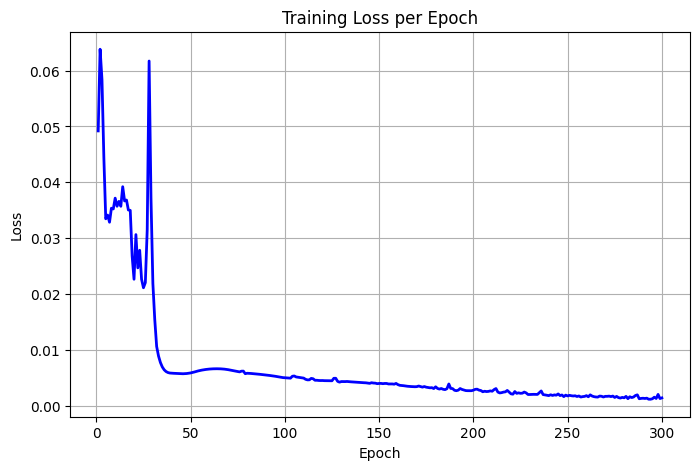

In [19]:

import matplotlib.pyplot as plt
import time

# epochs = 200
epochs = 300
loss_history = []  # to store loss values

start_time = time.time()

for epoch in range(epochs):

    correct = 0
    total = 0
    epoch_loss = 0.0
    for x_train, y_train in train_data:
        optimizer.zero_grad() # Clears old gradients from the previous iteration
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step() # update weights
        epoch_loss += loss.item()


    # Save the last batch loss for plotting
    avg_loss = epoch_loss / len(train_data)
    loss_history.append(avg_loss)
    #print(f'Epoch: {epoch+1} Loss: {loss.item():10.8f}') # only print last batch
    print(f'Epoch: {epoch+1} Loss: {avg_loss:10.8f}')

print(f'\nDuration: {time.time() - start_time:.0f} seconds')


# Plot the loss graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_history, color='blue', linewidth=2)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)



### 

## Prediction / predict 12 future time steps

In [20]:
window_size

12

In [21]:
df.head()

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


In [22]:
df.tail(13)

,S4248SM144NCEN
DATE,
2018-01-01,9564
2018-02-01,10415
2018-03-01,12683
2018-04-01,11919
2018-05-01,14138
2018-06-01,14583
2018-07-01,12640
2018-08-01,14257
2018-09-01,12396


In [23]:
train_norm[-window_size:]

tensor([0.2687, 0.6155, 0.4463, 0.7974, 1.0000, 0.4335, 0.7730, 0.5174, 0.6548,
        0.7489, 0.9205, 0.1168])

In [24]:
print(test_norm)
# test_norm.reshape(-1)

[[0.26233011]
 [0.65005556]
 [0.51944611]
 [0.89879477]
 [0.97486965]
 [0.6427045 ]
 [0.91913839]
 [0.60099154]
 [0.8605009 ]
 [0.90494914]
 [1.132319  ]
 [0.31412941]]


### Teacher forcing (uses REAL test values)

In [25]:
model.eval()

future = test_size
data_tf = train_norm[-window_size:].tolist()
pred_tf = []

test_real_norm = test_norm.reshape(-1)

for i in range(future):
    seq = torch.FloatTensor(data_tf[-window_size:])
    with torch.no_grad():
        yhat = model(seq).item()
    pred_tf.append(yhat)

    # teacher forcing: append REAL value
    data_tf.append(float(test_real_norm[i]))

### Recursive forecast (uses PREDICTED values only)

In [26]:
data_rec = train_norm[-window_size:].tolist()
pred_rec = []

for i in range(future):
    seq = torch.FloatTensor(data_rec[-window_size:])
    with torch.no_grad():
        yhat = model(seq).item()
    pred_rec.append(yhat)

    # recursive: append prediction
    data_rec.append(yhat)

### Inverse transform back to original scale

In [27]:
pred_tf = scaler.inverse_transform(np.array(pred_tf).reshape(-1,1)).ravel() # ravel() converts the array into a 1-D (
pred_rec = scaler.inverse_transform(np.array(pred_rec).reshape(-1,1)).ravel()

### Align dates correctly 

In [28]:
actual = df['S4248SM144NCEN'].iloc[-test_size:]
dates = actual.index

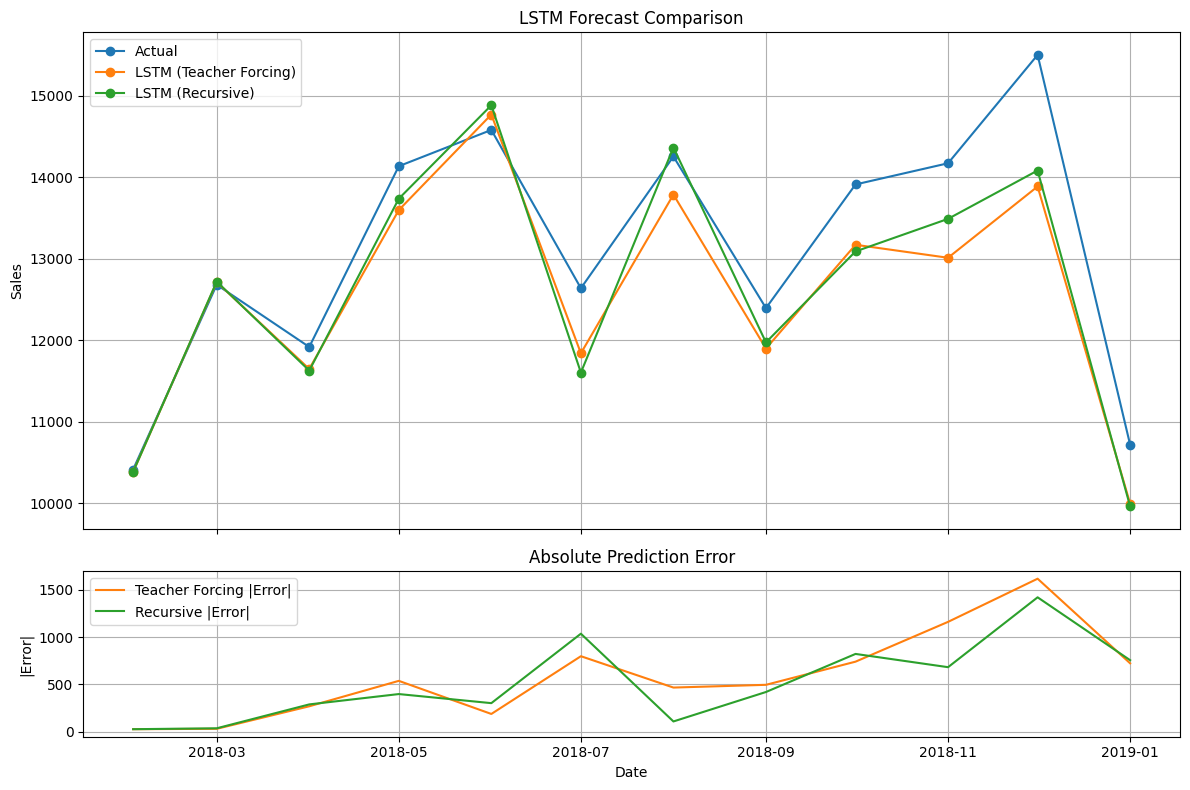

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- absolute errors ---
abs_err_tf = np.abs(pred_tf - actual.values)
abs_err_rec = np.abs(pred_rec - actual.values)

# choose colors (explicit & consistent)
color_tf = "tab:orange"
color_rec = "tab:green"
color_actual = "tab:blue"

# --- create subplots ---
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# ===== TOP: actual vs predictions =====
ax1.plot(actual.index, actual.values,
         label="Actual", marker='o', color=color_actual)

ax1.plot(dates, pred_tf,
         label="LSTM (Teacher Forcing)", marker='o', color=color_tf)

ax1.plot(dates, pred_rec,
         label="LSTM (Recursive)", marker='o', color=color_rec)

ax1.set_title("LSTM Forecast Comparison")
ax1.set_ylabel("Sales")
ax1.grid(True)
ax1.legend(loc="upper left")

# ===== BOTTOM: absolute errors =====
ax2.plot(dates, abs_err_tf,
         label="Teacher Forcing |Error|", color=color_tf)

ax2.plot(dates, abs_err_rec,
         label="Recursive |Error|", color=color_rec)

ax2.set_title("Absolute Prediction Error")
ax2.set_ylabel("|Error|")
ax2.set_xlabel("Date")
ax2.grid(True)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

#  RNN

In [30]:
# ----- build sequences 
window_size = 12

def create_sequences(series, window_size):
    seqs = []
    for i in range(len(series) - window_size):
        x = series[i:i+window_size]
        y = series[i+window_size:i+window_size+1]
        seqs.append((x, y))
    return seqs

train_data_rnn = create_sequences(train_norm, window_size)

## PLOTS

In [ ]:
hidden_size = hidden_size
class RNNnetwork(nn.Module):
    def __init__(self, input_size=1, hidden_size=hidden_size, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
       

        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, seq):
        seq = seq.view(len(seq), 1, 1)  # (seq_len, batch=1, input=1)
        h0 = torch.zeros(1, 1, self.hidden_size)
        rnn_out, _ = self.rnn(seq, h0)
        pred = self.linear(rnn_out[-1])  # last timestep
        return pred






In [32]:
# ----- train RNN -----
torch.manual_seed(42)

rnn_model = RNNnetwork(hidden_size=hidden_size)
criterion = nn.MSELoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)



In [33]:
! pip install torchinfo
from torchinfo import summary

print(summary(model, input_size=(12, 1, 1))) # seq_len=12, batch=1, features=1


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.14/bin/python3.14 -m pip install --upgrade pip
Layer (type:depth-idx)                   Output Shape              Param #
LSTMnetwork                              [1, 1]                    --
├─LSTM: 1-1                              [12, 1, 128]              67,072
├─Linear: 1-2                            [1, 1]                    129
Total params: 67,201
Trainable params: 67,201
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.80
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.27
Estimated Total Size (MB): 0.28


In [ ]:
epochs = 300
start_time = time.time()
loss_hstry = []  
for epoch in range(epochs):
    epoch_loss = 0.0
    for seq, y_train in train_data_rnn:
        rnn_optimizer.zero_grad()
        y_pred = rnn_model(seq)
        loss = criterion(y_pred.view(-1), y_train.view(-1))
        loss.backward()
        rnn_optimizer.step() # update weights
        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_data_rnn)
    loss_hstry.append(average_loss)
    print(f"Epoch {epoch+1:3d} | Loss: {average_loss:.6f}")

print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch   1 | Loss: 0.041743
Epoch   2 | Loss: 0.045652
Epoch   3 | Loss: 0.045984
Epoch   4 | Loss: 0.046176
Epoch   5 | Loss: 0.036588
Epoch   6 | Loss: 0.059226
Epoch   7 | Loss: 0.029808
Epoch   8 | Loss: 0.019710
Epoch   9 | Loss: 0.028170
Epoch  10 | Loss: 0.036402
Epoch  11 | Loss: 0.015315
Epoch  12 | Loss: 0.014495
Epoch  13 | Loss: 0.014516
Epoch  14 | Loss: 0.016797
Epoch  15 | Loss: 0.027499
Epoch  16 | Loss: 0.037654
Epoch  17 | Loss: 0.060556
Epoch  18 | Loss: 0.057950
Epoch  19 | Loss: 0.070488
Epoch  20 | Loss: 0.067157
Epoch  21 | Loss: 0.070186
Epoch  22 | Loss: 0.069723
Epoch  23 | Loss: 0.070213
Epoch  24 | Loss: 0.060404
Epoch  25 | Loss: 0.069125
Epoch  26 | Loss: 0.068665
Epoch  27 | Loss: 0.054387
Epoch  28 | Loss: 0.044981
Epoch  29 | Loss: 0.027663
Epoch  30 | Loss: 0.033141
Epoch  31 | Loss: 0.082093
Epoch  32 | Loss: 0.032828
Epoch  33 | Loss: 0.067247
Epoch  34 | Loss: 0.069451
Epoch  35 | Loss: 0.069187
Epoch  36 | Loss: 0.068536
Epoch  37 | Loss: 0.076969
E

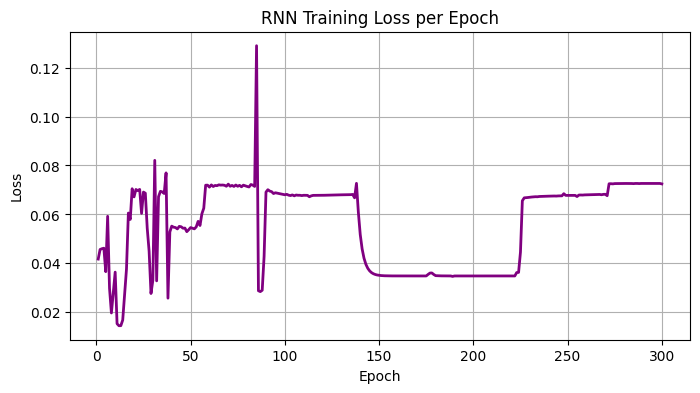

In [35]:
# plot the loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), loss_hstry, color='purple', linewidth=2)
plt.title('RNN Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [36]:
rnn_model.eval()

test_size = 12
actual = df['S4248SM144NCEN'].iloc[-test_size:]
dates = actual.index
y_true = actual.values

test_real_norm = test_norm.reshape(-1)

# ============ RNN Teacher Forcing ============
inputs_tf = train_norm[-window_size:].tolist()
pred_tf_rnn = []

for i in range(test_size):
    seq = torch.FloatTensor(inputs_tf[-window_size:])
    with torch.no_grad():
        yhat = rnn_model(seq).item()
    pred_tf_rnn.append(yhat)
    inputs_tf.append(float(test_real_norm[i]))  # REAL value

# ============ RNN Recursive ============
inputs_rec = train_norm[-window_size:].tolist()
pred_rec_rnn = []

for i in range(test_size):
    seq = torch.FloatTensor(inputs_rec[-window_size:])
    with torch.no_grad():
        yhat = rnn_model(seq).item()
    pred_rec_rnn.append(yhat)
    inputs_rec.append(yhat)  # PRED value

# inverse scale
pred_tf_rnn = scaler.inverse_transform(np.array(pred_tf_rnn).reshape(-1, 1)).ravel()
pred_rec_rnn = scaler.inverse_transform(np.array(pred_rec_rnn).reshape(-1, 1)).ravel()

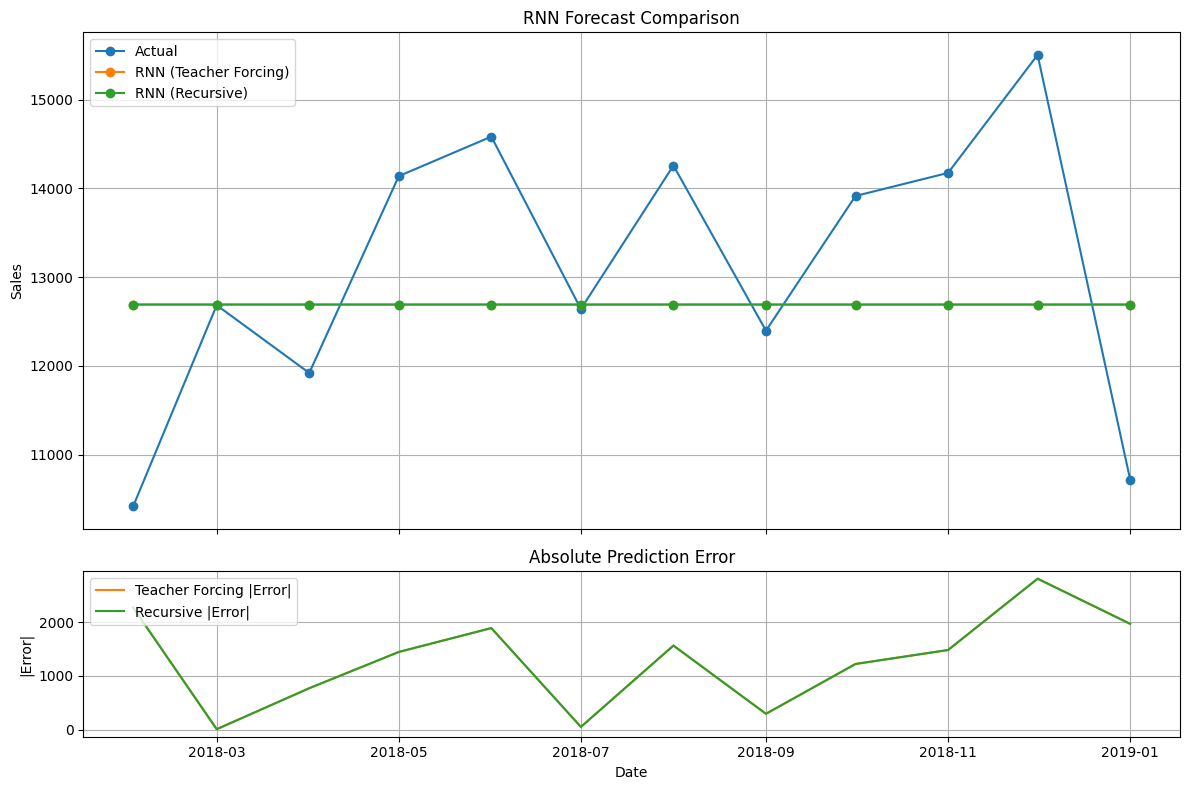

In [37]:
import numpy as np
import matplotlib.pyplot as plt

abs_err_tf_rnn = np.abs(pred_tf_rnn - y_true)
abs_err_rec_rnn = np.abs(pred_rec_rnn - y_true)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.plot(dates, y_true, label="Actual", marker="o", color="tab:blue")
ax1.plot(dates, pred_tf_rnn, label="RNN (Teacher Forcing)", marker="o", color="tab:orange")
ax1.plot(dates, pred_rec_rnn, label="RNN (Recursive)", marker="o", color="tab:green")
ax1.set_title("RNN Forecast Comparison")
ax1.set_ylabel("Sales")
ax1.grid(True)
ax1.legend(loc="upper left")

ax2.plot(dates, abs_err_tf_rnn, label="Teacher Forcing |Error|", color="tab:orange")
ax2.plot(dates, abs_err_rec_rnn, label="Recursive |Error|", color="tab:green")
ax2.set_title("Absolute Prediction Error")
ax2.set_ylabel("|Error|")
ax2.set_xlabel("Date")
ax2.grid(True)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [38]:
pred_tf_lstm = pred_tf
pred_rec_lstm = pred_rec

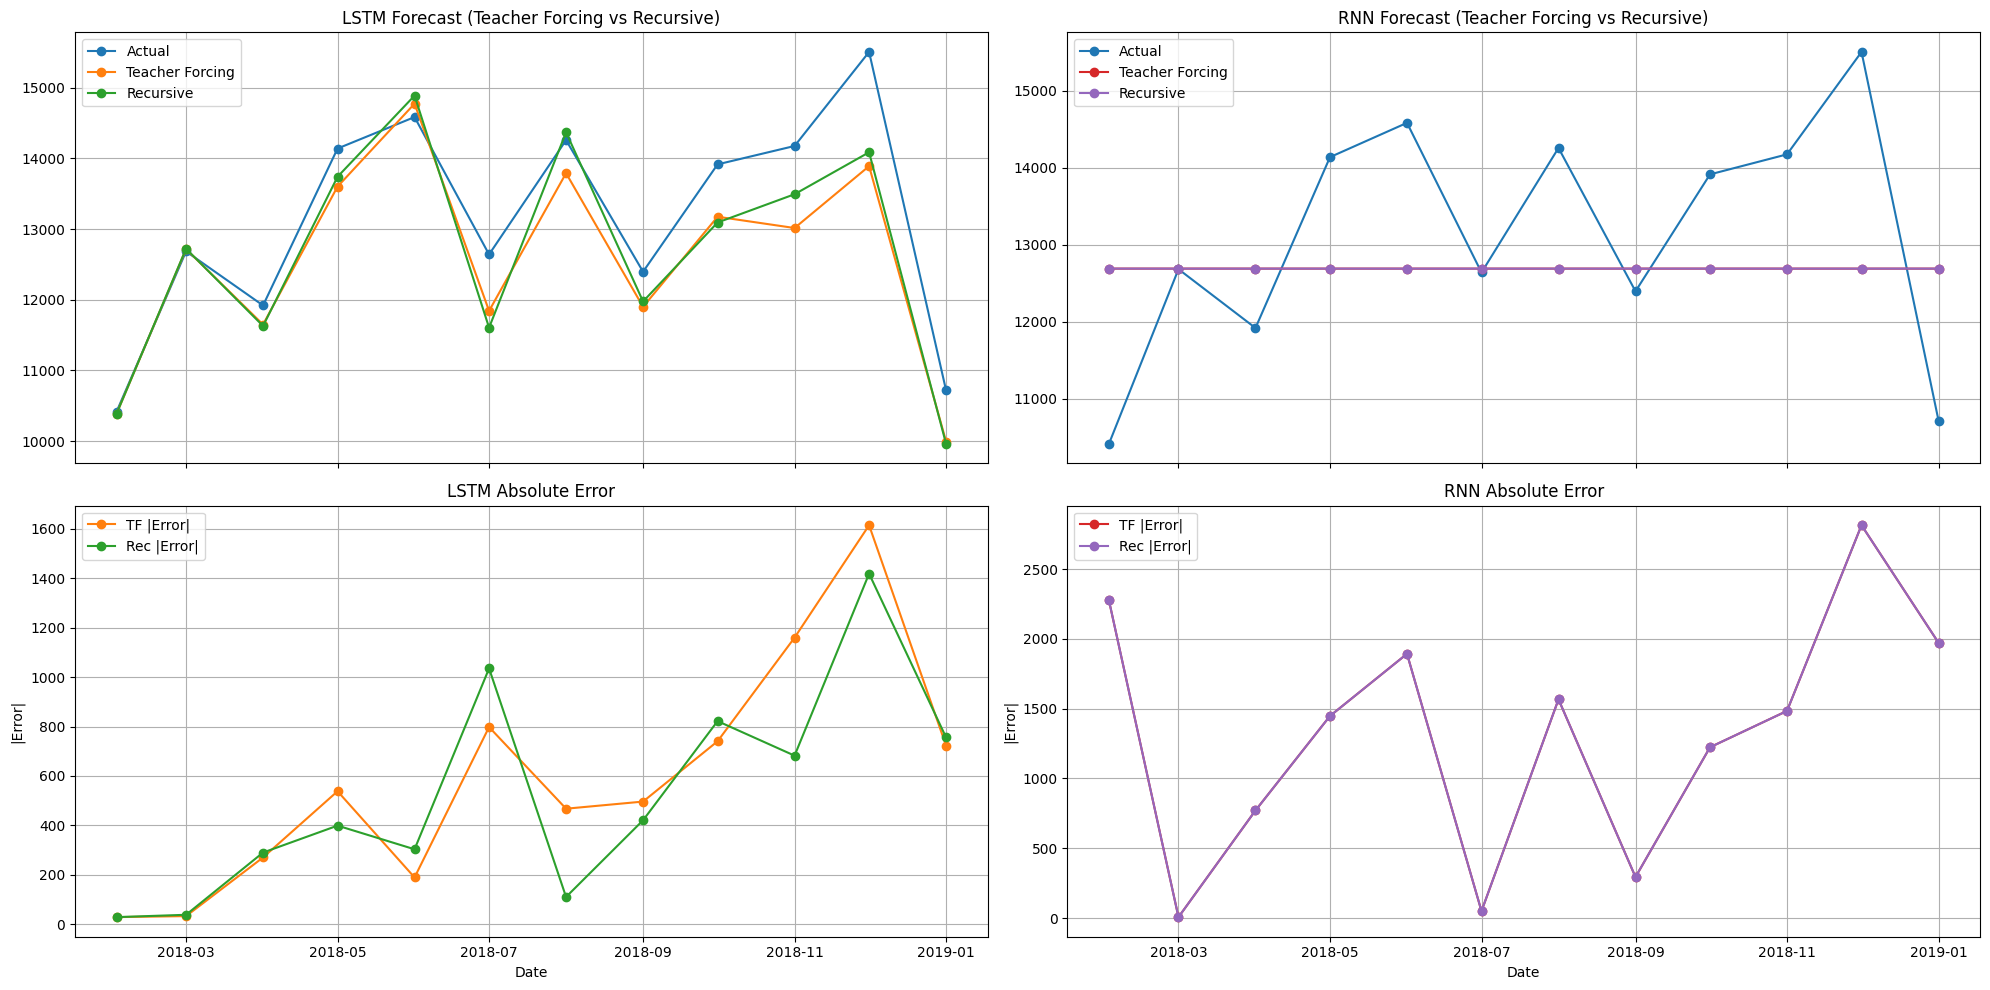

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# --- dates / actual ---
dates = actual.index
y_true = actual.values

# --- absolute errors ---
abs_err_tf_lstm  = np.abs(pred_tf_lstm  - y_true)
abs_err_rec_lstm = np.abs(pred_rec_lstm - y_true)

abs_err_tf_rnn   = np.abs(pred_tf_rnn   - y_true)
abs_err_rec_rnn  = np.abs(pred_rec_rnn  - y_true)

# choose colors
color_actual   = "tab:blue"
color_tf_lstm  = "tab:orange"
color_rec_lstm = "tab:green"
color_tf_rnn   = "tab:red"
color_rec_rnn  = "tab:purple"

# --- 2x2 figure (Forecasts on top, Errors on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex='col')

# ================= LEFT: LSTM Forecast =================
ax = axes[0, 0]
ax.set_title("LSTM Forecast (Teacher Forcing vs Recursive)")
ax.plot(dates, y_true,        label="Actual", marker="o", color=color_actual)
ax.plot(dates, pred_tf_lstm,  label="Teacher Forcing", marker="o", color=color_tf_lstm)
ax.plot(dates, pred_rec_lstm, label="Recursive",       marker="o", color=color_rec_lstm)
ax.grid(True)
ax.legend(loc="upper left")

# ================= LEFT: LSTM Abs Error =================
ax = axes[1, 0]
ax.set_title("LSTM Absolute Error")
ax.plot(dates, abs_err_tf_lstm,  label="TF |Error|", marker="o", color=color_tf_lstm)
ax.plot(dates, abs_err_rec_lstm, label="Rec |Error|", marker="o", color=color_rec_lstm)
ax.grid(True)
ax.legend(loc="upper left")
ax.set_xlabel("Date")
ax.set_ylabel("|Error|")

# ================= RIGHT: RNN Forecast =================
ax = axes[0, 1]
ax.set_title("RNN Forecast (Teacher Forcing vs Recursive)")
ax.plot(dates, y_true,       label="Actual", marker="o", color=color_actual)
ax.plot(dates, pred_tf_rnn,  label="Teacher Forcing", marker="o", color=color_tf_rnn)
ax.plot(dates, pred_rec_rnn, label="Recursive",       marker="o", color=color_rec_rnn)
ax.grid(True)
ax.legend(loc="upper left")

# ================= RIGHT: RNN Abs Error =================
ax = axes[1, 1]
ax.set_title("RNN Absolute Error")
ax.plot(dates, abs_err_tf_rnn,  label="TF |Error|", marker="o", color=color_tf_rnn)
ax.plot(dates, abs_err_rec_rnn, label="Rec |Error|", marker="o", color=color_rec_rnn)
ax.grid(True)
ax.legend(loc="upper left")
ax.set_xlabel("Date")
ax.set_ylabel("|Error|")

plt.tight_layout()
plt.show()